In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/playground-series-s6e8/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e8/train.csv
/kaggle/input/competitions/playground-series-s6e8/test.csv


# Predicting Smart Phone Addiction
## Import Training Dataset & Processing

/kaggle/input/competitions/playground-series-s6e8/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e8/train.csv
/kaggle/input/competitions/playground-series-s6e8/test.csv


Dimensions of the DataFrame
(691369, 14)

--------------------------------------------------------------------------------

Summary of the DataFrame's structure
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non

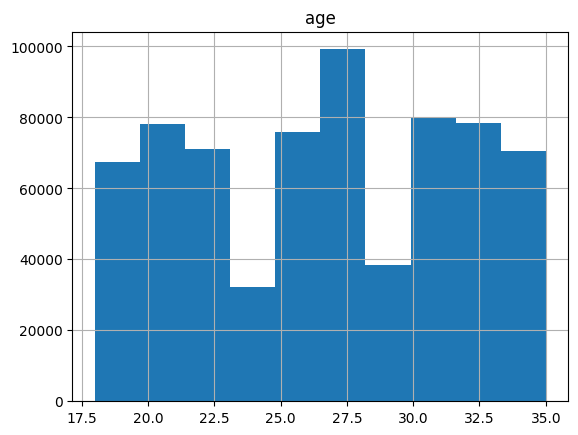


--------------------------------------------------------------------------------

daily_screen_time_hours skewness: -0.13197209083432848
Filling NaNs in 'daily_screen_time_hours' with mean value: 7.640865487855051


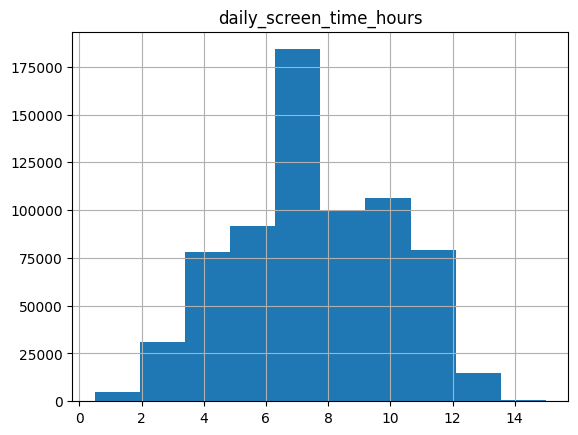


--------------------------------------------------------------------------------

social_media_hours skewness: 0.468081393910621
Filling NaNs in 'social_media_hours' with mean value: 2.4710382077384314


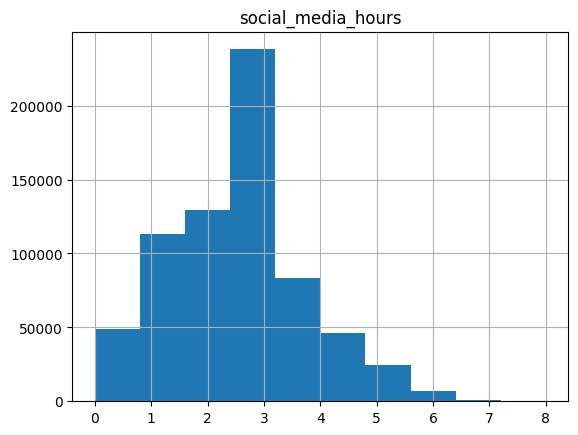


--------------------------------------------------------------------------------

gaming_hours skewness: 0.5447396028536303
Filling NaNs in 'gaming_hours' with median value: 1.33


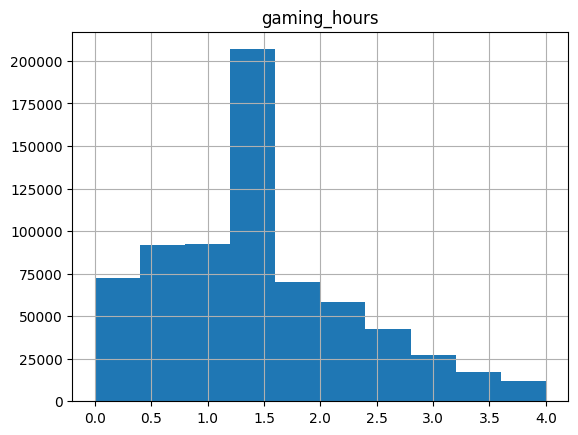


--------------------------------------------------------------------------------

work_study_hours skewness: 0.5634570530721745
Filling NaNs in 'work_study_hours' with median value: 2.2


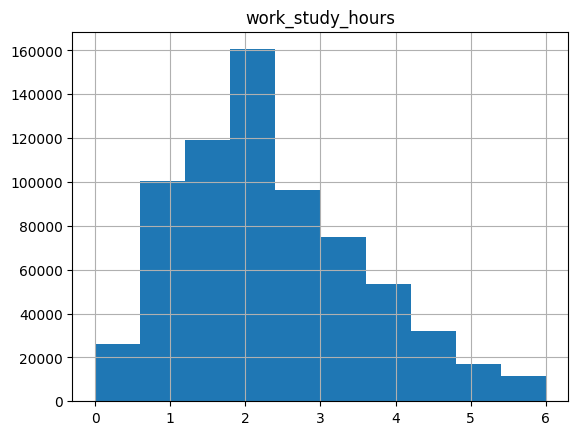


--------------------------------------------------------------------------------

sleep_hours skewness: -0.00658666980407133
Filling NaNs in 'sleep_hours' with mean value: 6.804334097503589


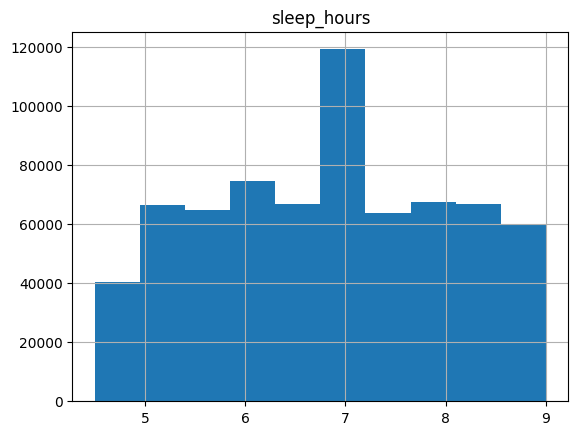


--------------------------------------------------------------------------------

notifications_per_day skewness: -0.20653513389695957
Filling NaNs in 'notifications_per_day' with mean value: 145.89489968498762


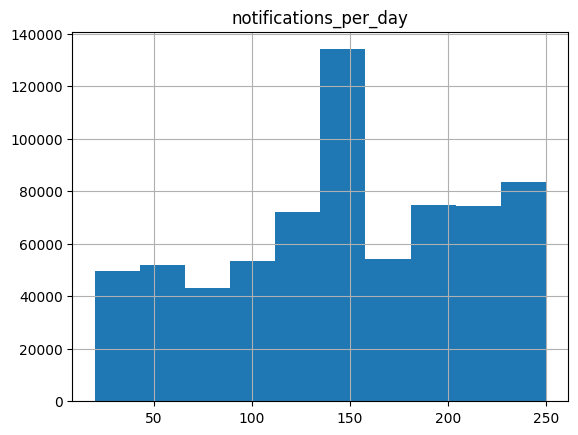


--------------------------------------------------------------------------------

app_opens_per_day skewness: -0.126463220385457
Filling NaNs in 'app_opens_per_day' with mean value: 102.63678092028448


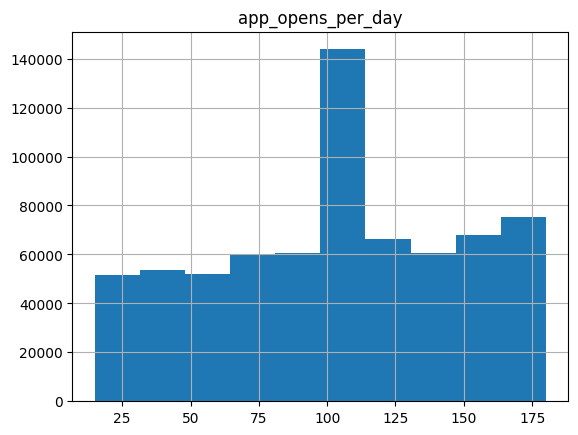


--------------------------------------------------------------------------------

weekend_screen_time skewness: -0.06340829123835504
Filling NaNs in 'weekend_screen_time' with mean value: 9.479866442778084


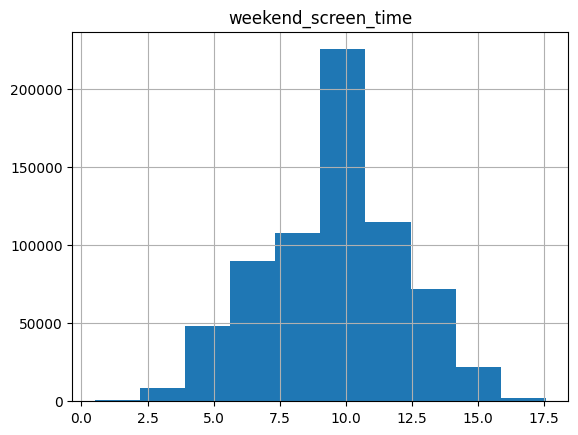


--------------------------------------------------------------------------------


Filling NaN values in categorical features with mode

Filling NaN in 'gender' with mode: Male

Filling NaN in 'stress_level' with mode: High

Filling NaN in 'academic_work_impact' with mode: Yes


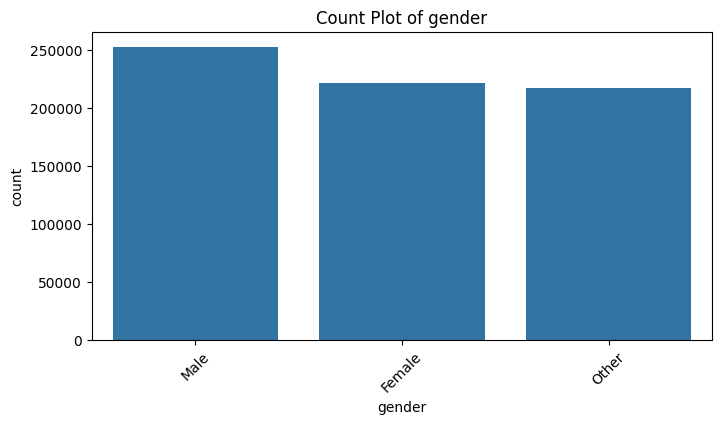


--------------------------------------------------------------------------------


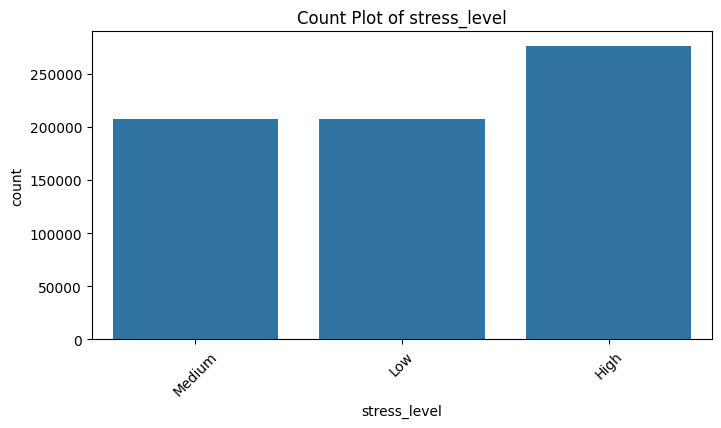


--------------------------------------------------------------------------------


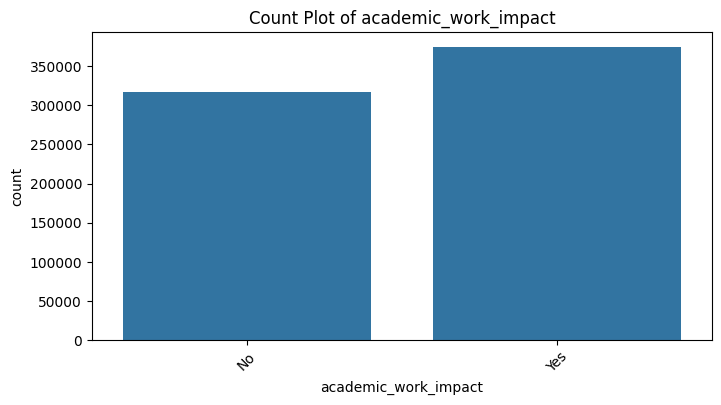


--------------------------------------------------------------------------------

Total integer features with zero: 0
1. social_media_hours (float64) - Zero count: 12
2. gaming_hours (float64) - Zero count: 110
3. work_study_hours (float64) - Zero count: 5

Total float features with zero: 3
gender (object):
gender
Male      252696
Female    221595
Other     217078
Name: count, dtype: int64

******************************

stress_level (object):
stress_level
High      276021
Low       207783
Medium    207565
Name: count, dtype: int64

******************************

academic_work_impact (object):
academic_work_impact
Yes    374790
No     316579
Name: count, dtype: int64

******************************



In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder, OneHotEncoder

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization
from keras.callbacks import EarlyStopping
import keras_tuner as kt

# List input files
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Load train data
train_path = '/kaggle/input/competitions/playground-series-s6e8/train.csv'
df = pd.read_csv(train_path)

# Basic info and preview
print("\n" + "="*80 + "\n")
print("Dimensions of the DataFrame")
print(df.shape)
print("\n" + "-"*80 )
print("\nSummary of the DataFrame's structure")
print(df.info())
print("\n" + "-"*80 )
print("\nTotal number of missing data")
print(df.isna().sum())
print("\n" + "="*80)

# Automate filling NaN for numerical features based on skewness
print("\nAnalyzing Numerical Features for Skewness and Filling NaNs Accordingly\n")
for col in df.columns[1:-1]:
    if df[col].dtype != 'object':
        sk = df[col].skew()
        print(f'{col} skewness: {sk}')
        if -0.5 < sk < 0.5:
            fill_value = df[col].mean()
            method = 'mean'
        else:
            fill_value = df[col].median()
            method = 'median'
        print(f"Filling NaNs in '{col}' with {method} value: {fill_value}")
        df[col] = df[col].fillna(fill_value)
        # Plot histogram
        plt.title(col)
        df[col].hist()
        plt.show()
        print("\n" + "-"*80 + "\n")

# Automate filling NaN for categorical features with mode
print("\nFilling NaN values in categorical features with mode")
for col in df.select_dtypes(include='object').columns:
    mode_value = df[col].mode()[0]
    print("\n" + "="*80)
    print(f"Filling NaN in '{col}' with mode: {mode_value}")
    df[col] = df[col].fillna(mode_value)

# Loop through categorical columns and plot count plots
for col in df.select_dtypes(include='object').columns:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, data=df)
    plt.title(f'Count Plot of {col}')
    plt.xticks(rotation=45)
    plt.show()
    print("\n" + "-"*80)
    
# Check for zero values in numerical features
j = 0
for col in df.columns[1:-1]:
    if df[col].dtype == 'int64' and (df[col] == 0).sum() != 0:
        print(f"{j+1}. {col} ({df[col].dtype}) - Zero count: {(df[col] == 0).sum()}")
        j += 1
print(f"\nTotal integer features with zero: {j}")

j = 0
for col in df.columns[1:-1]:
    if df[col].dtype == 'float64' and (df[col] == 0).sum() != 0:
        print(f"{j+1}. {col} ({df[col].dtype}) - Zero count: {(df[col] == 0).sum()}")
        j += 1
print(f"\nTotal float features with zero: {j}")

# Explore object columns
for col in df.select_dtypes(include='object').columns:
    print(f"{col} ({df[col].dtype}):")
    print(df[col].value_counts())
    print("\n" + "*"*30 + "\n")



## Importing Testing Dataset & Processing 



Dimensions of the DataFrame
(296302, 13)

--------------------------------------------------------------------------------

Summary of the DataFrame's structure
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296302 entries, 0 to 296301
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       296302 non-null  int64  
 1   age                      279164 non-null  float64
 2   daily_screen_time_hours  263514 non-null  float64
 3   social_media_hours       248905 non-null  float64
 4   gaming_hours             236882 non-null  float64
 5   work_study_hours         268525 non-null  float64
 6   sleep_hours              273847 non-null  float64
 7   notifications_per_day    262081 non-null  float64
 8   app_opens_per_day        270597 non-null  float64
 9   weekend_screen_time      245605 non-null  float64
 10  gender                   282090 non-null  object 
 11  stress

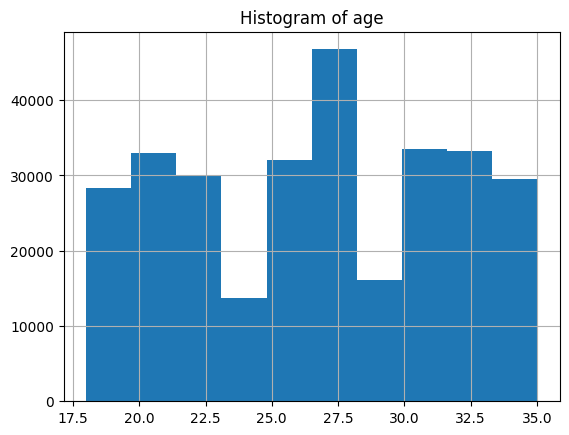


***************************************************************************

daily_screen_time_hours skewness: -0.1308451686597246
Filled NaN in daily_screen_time_hours with mean: 7.640770737038639


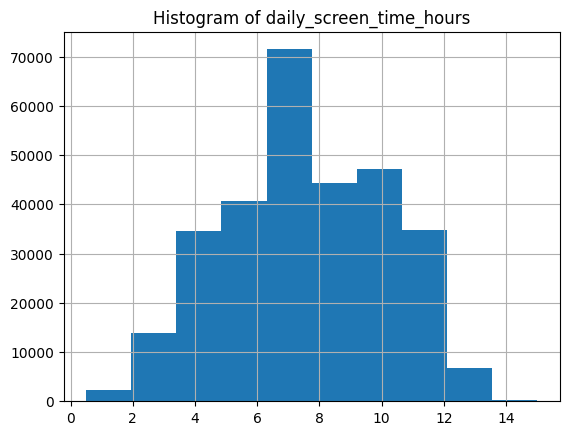


***************************************************************************

social_media_hours skewness: 0.4717692499494669
Filled NaN in social_media_hours with mean: 2.4712239609489557


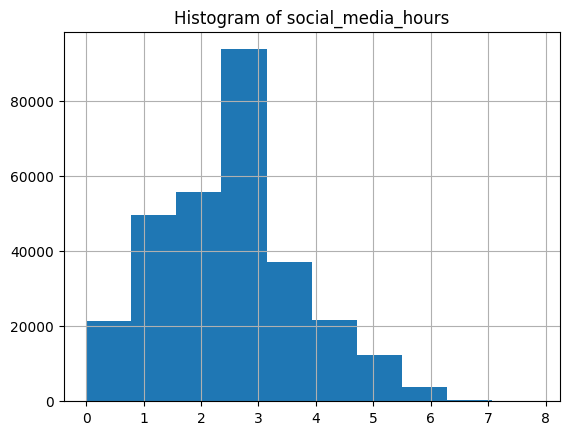


***************************************************************************

gaming_hours skewness: 0.5450086314908379
Filled NaN in gaming_hours with median: 1.33


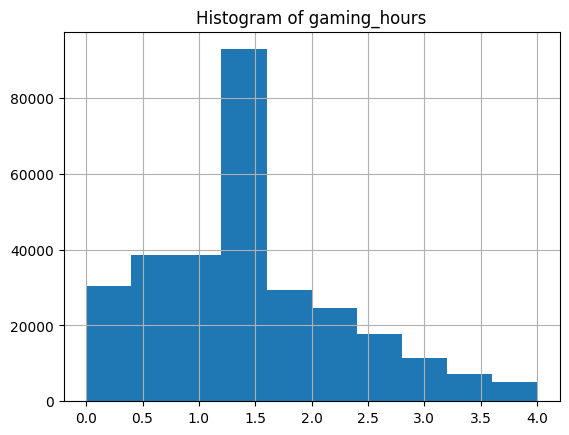


***************************************************************************

work_study_hours skewness: 0.5623996855302822
Filled NaN in work_study_hours with median: 2.2


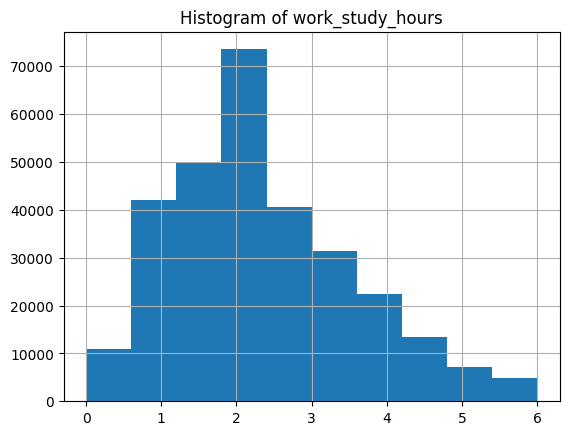


***************************************************************************

sleep_hours skewness: -0.007079753831678084
Filled NaN in sleep_hours with mean: 6.801704309340617


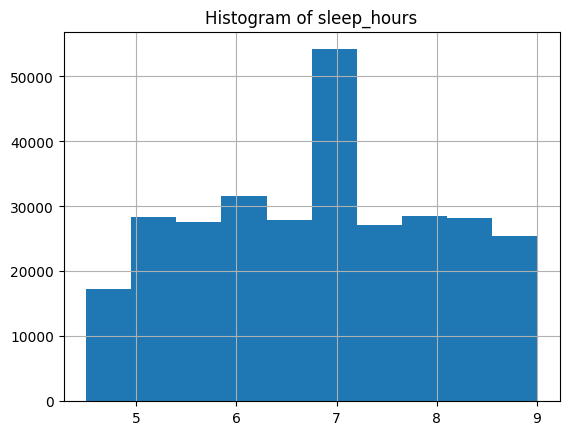


***************************************************************************

notifications_per_day skewness: -0.2028126675993759
Filled NaN in notifications_per_day with mean: 145.74806643747544


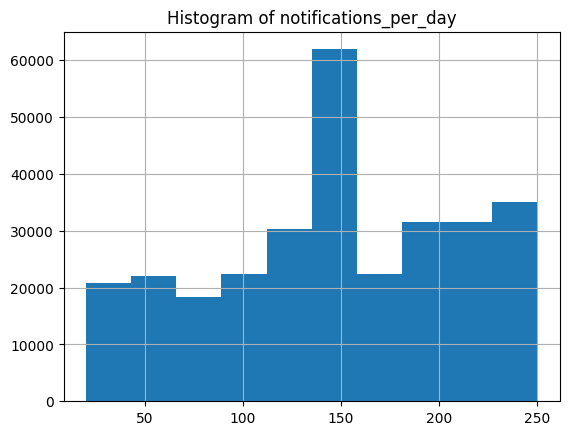


***************************************************************************

app_opens_per_day skewness: -0.12534293278560346
Filled NaN in app_opens_per_day with mean: 102.65621570083925


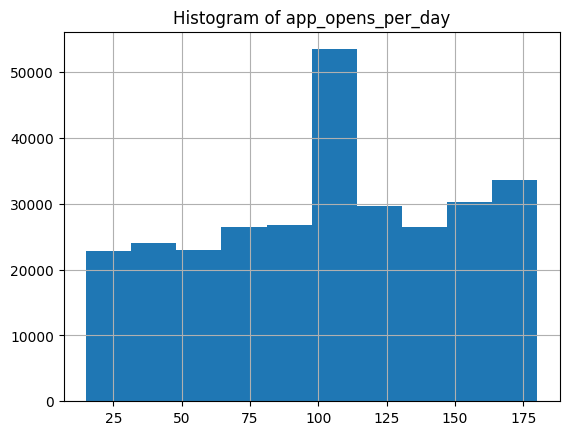


***************************************************************************

weekend_screen_time skewness: -0.06518549027941012
Filled NaN in weekend_screen_time with mean: 9.474574975672324


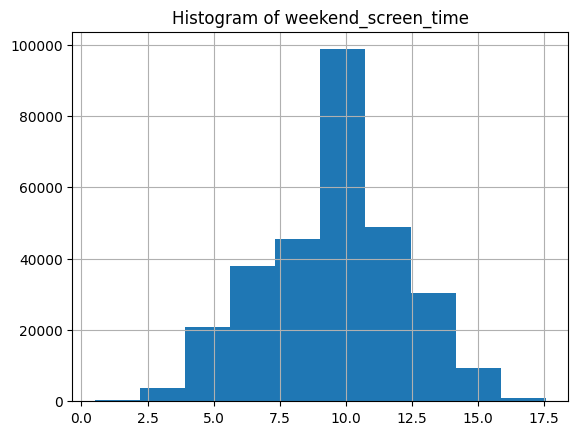


***************************************************************************

Categorical Data Visualization for Test Data


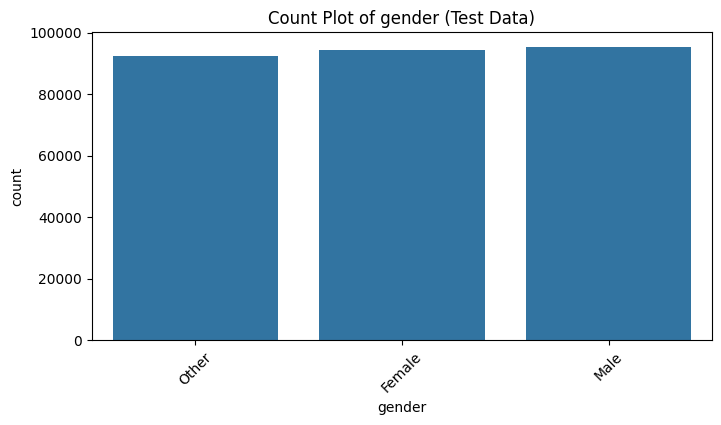

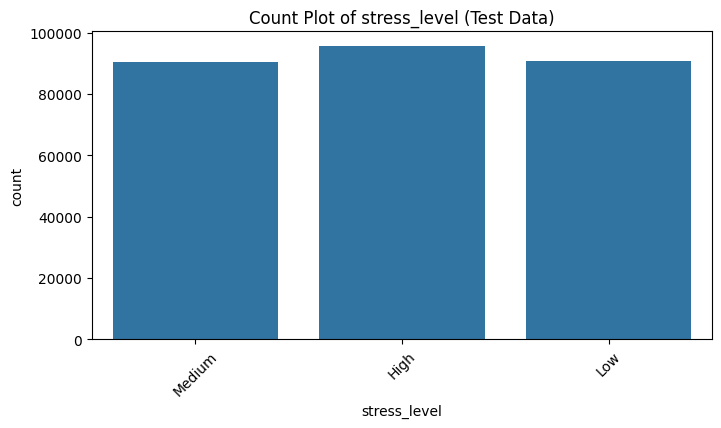

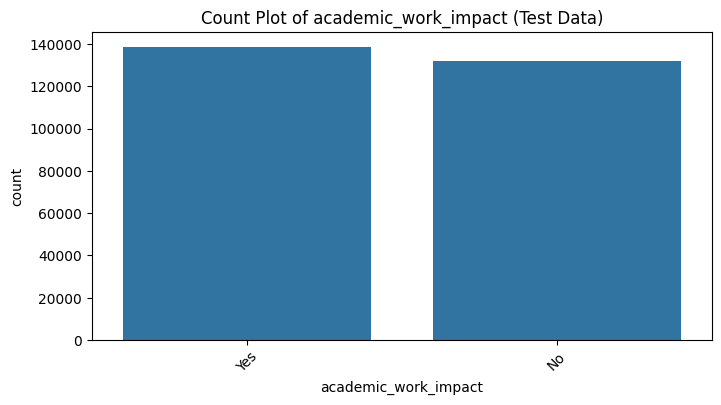


Total integer features with zero in test: 0
1. social_media_hours (float64) - Zero count: 4
2. gaming_hours (float64) - Zero count: 40
3. work_study_hours (float64) - Zero count: 1

Total float features with zero in test: 3
gender (object):
gender
Male      95357
Female    94295
Other     92438
Name: count, dtype: int64

------------------------------

stress_level (object):
stress_level
High      95622
Low       90746
Medium    90308
Name: count, dtype: int64

------------------------------

academic_work_impact (object):
academic_work_impact
Yes    138694
No     131887
Name: count, dtype: int64

------------------------------



In [3]:
# Load test data
test_path = '/kaggle/input/competitions/playground-series-s6e8/test.csv'
test = pd.read_csv(test_path)

# Similar analysis and filling for test data
# Basic info and preview
print("\n" + "="*80 + "\n")
print("Dimensions of the DataFrame")
print(test.shape)
print("\n" + "-"*80 )
print("\nSummary of the DataFrame's structure")
print(test.info())
print("\n" + "-"*80 )
print("\nTotal number of missing data")
print(test.isna().sum())
print("\n" + "="*80)

# --- Numerical Data Analysis and NaN Filling for Test Data ---
print("Numerical Data Analysis and NaN Filling for Test Data")
# --- Numerical Data Analysis and NaN Filling for Test Data ---
print("Numerical Data Analysis and NaN Filling for Test Data")
for col in test.columns[1:]:
    if np.issubdtype(test[col].dtype, np.number):
        sk = test[col].skew()
        print(f'{col} skewness: {sk}')
        # Decide whether to fill NaNs with mean or median
        if -0.5 < sk < 0.5:
            test[col] = test[col].fillna(test[col].mean())
            print(f"Filled NaN in {col} with mean: {test[col].mean()}")
        else:
            test[col] = test[col].fillna(test[col].median())
            print(f"Filled NaN in {col} with median: {test[col].median()}")
        # Plot histogram
        plt.figure()
        test[col].hist()
        plt.title(f'Histogram of {col}')
        plt.show()
        print("\n" + "*"*75 + "\n")
        
# --- Categorical Data Visualization ---
print("Categorical Data Visualization for Test Data")

for col in test.select_dtypes(include='object').columns:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, data=test)
    plt.title(f'Count Plot of {col} (Test Data)')
    plt.xticks(rotation=45)
    plt.show()

# --- Zero Value Check in Test Data ---
j = 0
for col in test.columns[1:]:
    if (test[col].dtype == 'int64') and (test[col] == 0).sum() != 0:
        print(f"{j+1}. {col} ({test[col].dtype}) - Zero count: {(test[col] == 0).sum()}")
        j += 1
print(f"\nTotal integer features with zero in test: {j}")

j = 0
for col in test.columns[1:]:
    if (test[col].dtype == 'float64') and (test[col] == 0).sum() != 0:
        print(f"{j+1}. {col} ({test[col].dtype}) - Zero count: {(test[col] == 0).sum()}")
        j += 1
print(f"\nTotal float features with zero in test: {j}")

# Explore object columns
for col in test.select_dtypes(include='object').columns:
    print(f"{col} ({test[col].dtype}):")
    print(test[col].value_counts())
    print("\n" + "-"*30 + "\n")


## Preprocess data for modeling

Object columns in train dataset:
 - gender (object)
 - stress_level (object)
 - academic_work_impact (object)

Object columns in test dataset:
 - gender (object)
 - stress_level (object)
 - academic_work_impact (object)

Generating Heat Map


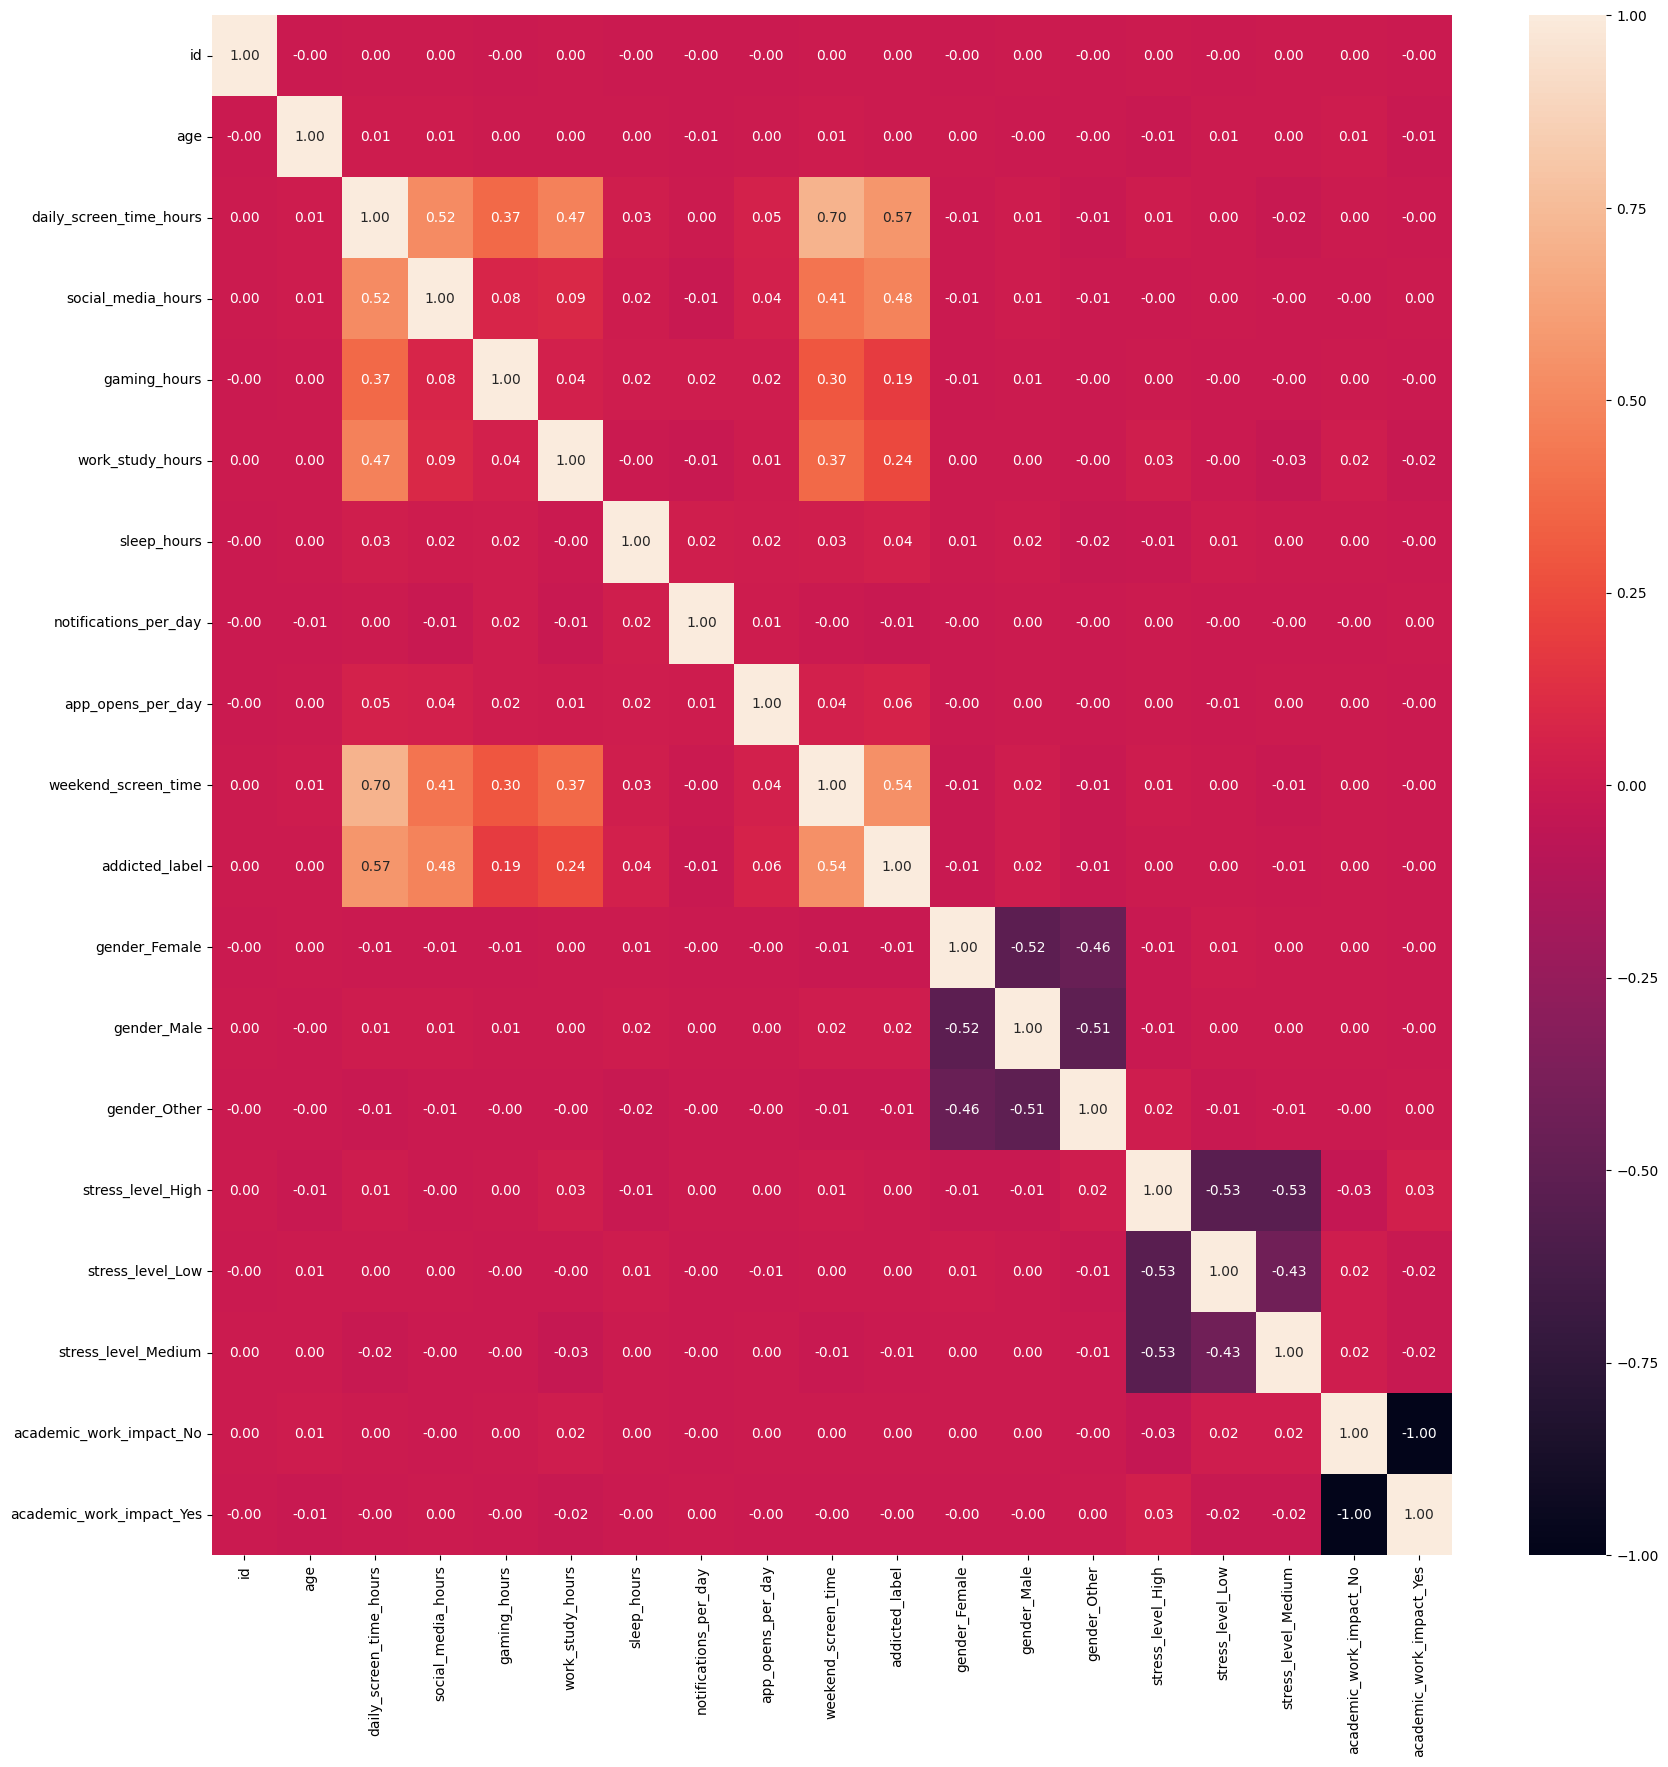


Correlation with 'addicted_label':
id                          0.001097
age                         0.003959
daily_screen_time_hours     0.567608
social_media_hours          0.478039
gaming_hours                0.185157
work_study_hours            0.241706
sleep_hours                 0.041165
notifications_per_day      -0.011003
app_opens_per_day           0.059688
weekend_screen_time         0.540113
addicted_label              1.000000
gender_Female              -0.008450
gender_Male                 0.020258
gender_Other               -0.012523
stress_level_High           0.002732
stress_level_Low            0.002506
stress_level_Medium        -0.005426
academic_work_impact_No     0.003249
academic_work_impact_Yes   -0.003249
Name: addicted_label, dtype: float64


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Function to check object (categorical) columns in train and test datasets
def check_object_columns(train_df, test_df):
    print("Object columns in train dataset:")
    for col in train_df.select_dtypes(include='object').columns:
        print(f" - {col} ({train_df[col].dtype})")
    print("\nObject columns in test dataset:")
    for col in test_df.select_dtypes(include='object').columns:
        print(f" - {col} ({test_df[col].dtype})")

# Function to encode categorical features using OneHotEncoder
def encode_categorical(train_df, test_df, categorical_columns):
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    encoder.fit(train_df[categorical_columns])
    train_encoded = encoder.transform(train_df[categorical_columns])
    test_encoded = encoder.transform(test_df[categorical_columns])
    encoded_cols = encoder.get_feature_names_out(categorical_columns)
    train_encoded_df = pd.DataFrame(train_encoded, columns=encoded_cols, index=train_df.index)
    test_encoded_df = pd.DataFrame(test_encoded, columns=encoded_cols, index=test_df.index)
    # Drop original categorical columns and concatenate encoded features
    train_df = pd.concat([train_df.drop(columns=categorical_columns), train_encoded_df], axis=1)
    test_df = pd.concat([test_df.drop(columns=categorical_columns), test_encoded_df], axis=1)
    return train_df, test_df
    

# Function to scale numerical features
def scale_numerical(train_df, test_df, numerical_columns):
    scaler = StandardScaler()
    train_df[numerical_columns] = scaler.fit_transform(train_df[numerical_columns])
    test_df[numerical_columns] = scaler.transform(test_df[numerical_columns])
    return train_df, test_df

# Function to generate correlation heatmap
def plot_correlation_heatmap(data, figsize=(20,20)):
    print("\nGenerating Heat Map")
    corr = data.corr()
    plt.figure(figsize=figsize)
    sns.heatmap(corr, annot=True, fmt='.2f')
    plt.show()

# Function to check correlation with target variable
def correlation_with_target(data, target_column):
    corr_target = data.corr()[target_column]
    print(f"\nCorrelation with '{target_column}':")
    print(corr_target)

# --- Main workflow ---

# Assuming df (train) and test are already loaded DataFrames
# Replace with your data loading code if needed

# Step 1: Check object columns
check_object_columns(df, test)

# Step 2: Encode categorical features
categorical_cols = ['gender', 'stress_level', 'academic_work_impact']
df, test = encode_categorical(df, test, categorical_cols)

# Step 3: Scale numerical features
numerical_cols = [
    'age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours',
    'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day',
    'weekend_screen_time'
]
df, test = scale_numerical(df, test, numerical_cols)

# Step 4: Generate correlation heatmap
plot_correlation_heatmap(df)

# Step 5: Check correlation with target variable
correlation_with_target(df, 'addicted_label')

## Modelling the dataset

X_train shape: (691369, 17)
y_train shape: (691369,)
Class weights: {np.int64(0): np.float64(1.7207222678513652), np.int64(1): np.float64(0.7047967884128414)}


2026-08-03 02:54:19.122963: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,825 (179.00 KB)

 Trainable params: 45,825 (179.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
17285/17285 ━━━━━━━━━━━━━━━━━━━━ 59s 3ms/step - accuracy: 0.8237 - auc: 0.9259 - loss: 0.3353 - val_accuracy: 0.8279 - val_auc: 0.9332 - val_loss: 0.3366
Epoch 2/20
17285/17285 ━━━━━━━━━━━━━━━━━━━━ 57s 3ms/step - accuracy: 0.8288 - auc: 0.9307 - loss: 0.3257 - val_accuracy: 0.8262 - val_auc: 0.9346 - val_loss: 0.3331
Epoch 3/20
17285/17285 ━━━━━━━━━━━━━━━━━━━━ 57s 3ms/step - accuracy: 0.8292 - auc: 0.9314 - loss: 0.3242 - val_accuracy: 0.8332 - val_auc: 0.9344 - val_loss: 0.3369
Epoch 4/20
17285/17285 ━━━━━━━━━━━━━━━━━━━━ 57s 3ms/step - accuracy: 0.8295 - auc: 0.9317 - loss: 0.3237 - val_accuracy: 0.8359 - val_auc: 0.9346 - val_loss: 0.3292
Epoch 5/20
17285/17285 ━━━━━━━━━━━━━━━━━━━━ 57s 3ms/step - accuracy: 0.8308 - auc: 0.9320 - loss: 0.3232 - val_accuracy: 0.8329 - val_auc: 0.9348 - val_loss: 0.3282
Epoch 6/20
17285/17285 ━━━━━━━━━━━━━━━━━━━━ 57s 3ms/step - accuracy: 0.8312 - auc: 0.9321 - loss: 0.3231 - val_accuracy: 0.8353 - val_auc: 0.9357 - val_loss: 0.3218
Epoch 7/20

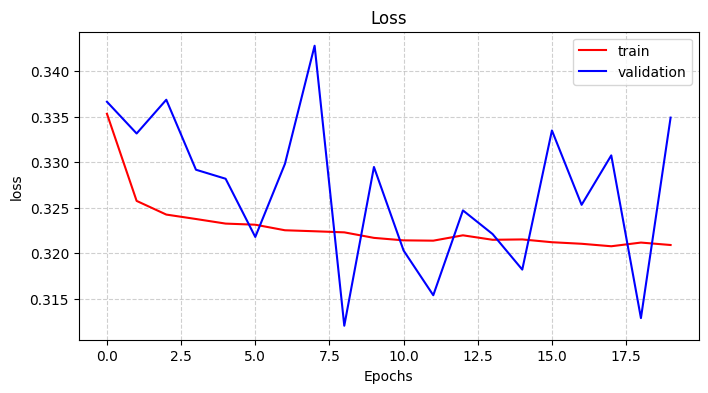

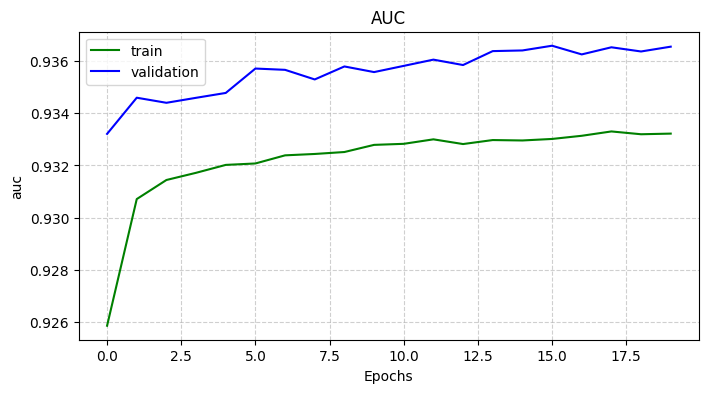

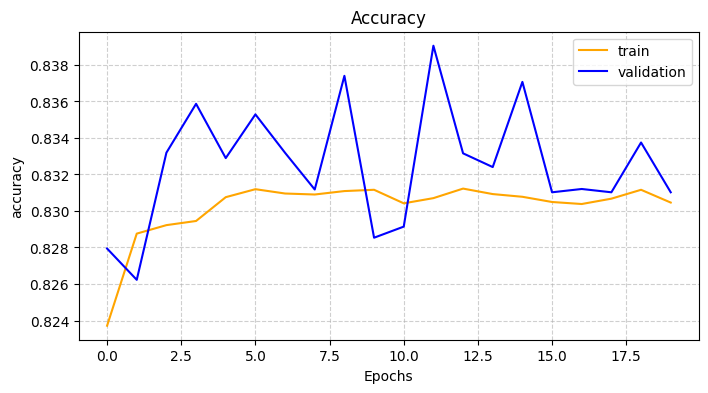

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout  # Added Input layer import
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight

# ==============================================================================
# 1. DATA PREPARATION
# ==============================================================================
# Extract features and targets
X_train = df.drop(columns=['id', 'addicted_label'])
y_train = df['addicted_label']

print('X_train shape:', X_train.shape)
print('y_train shape:', y_train.shape)

# Compute class weights to handle class imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(zip(np.unique(y_train), class_weights))
print("Class weights:", class_weight_dict)

# ==============================================================================
# 2. MODEL ARCHITECTURE & COMPILATION
# ==============================================================================
model = Sequential([
    Input(shape=(X_train.shape[1],)),  # Explicit Input layer (Fixes Keras 3 warning)
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.summary()

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(
    optimizer=optimizer, 
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='auc'), 'accuracy']
)

callback = EarlyStopping(
    monitor='val_auc',
    mode='max',               # Explicitly maximize validation AUC
    verbose=1,
    patience=5,
    restore_best_weights=True
)

# ==============================================================================
# 3. TRAINING
# ==============================================================================
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[callback],
    class_weight=class_weight_dict
)

# ==============================================================================
# 4. PLOTTING METRICS
# ==============================================================================
def plot_metric(metric, title, color):
    plt.figure(figsize=(8, 4))
    plt.plot(history.history[metric], color=color, label='train')
    plt.plot(history.history['val_' + metric], color='blue', label='validation')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel(metric)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

plot_metric('loss', 'Loss', 'red')
plot_metric('auc', 'AUC', 'green')
plot_metric('accuracy', 'Accuracy', 'orange')



## Test Prediction and Submission

In [6]:
# ==============================================================================
# 5. TEST PREDICTION & SUBMISSION EXPORT
# ==============================================================================
X_test = test.drop(columns=['id'])

# Generate predicted probabilities
y_prob = model.predict(X_test)

# Round probabilities to 16 decimal places
y_prob_rounded = np.round(y_prob[:, 0], 16)

# Create submission DataFrame
submission = pd.DataFrame({
    "id": test["id"],
    "addicted_label": y_prob_rounded
})

# Save to CSV
submission.to_csv("submission.csv", index=False)
print("\nSubmission generated successfully!")
print(submission.head(10))


9260/9260 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step

Submission generated successfully!
       id  addicted_label
0  691369        0.797432
1  691370        0.682769
2  691371        0.880263
3  691372        0.815380
4  691373        0.973990
5  691374        0.508411
6  691375        0.746747
7  691376        0.439578
8  691377        0.911203
9  691378        0.578289
